# 05 — Some model comparison

Followed by Notebook 4, here I wanna test and try different models. Also briefly make intuition of how their performance on this object.


## 0. Setup 

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES  = PROJECT_ROOT / "outputs" / "tables"
for d in (FIGURES, TABLES):
    d.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / "df_clean_wide.csv")
mapping = pd.DataFrame({
    "Metadata_JCP2022": ["JCP2022_033924", "JCP2022_095995", "JCP2022_001418", "JCP2022_094347", "JCP2022_051785"],
    "drug_name":        ["DMSO", "hydroxyurea", "palbociclib", "etoposide", "resveratrol"],
})
df = df.merge(mapping, on="Metadata_JCP2022", how="left")
df = df[
    (df["Cells_AreaShape_FormFactor"] <= 1)   & (df["Nuclei_AreaShape_FormFactor"] <= 1) &
    (df["Cells_AreaShape_EulerNumber"] == 1)  & (df["Nuclei_AreaShape_EulerNumber"] == 1) &
    (df["NC_Ratio"] <= 1)                     & (df["NC_Ratio_Radius"] <= 1)
].copy()

FEATURES = [
    "Cells_AreaShape_BoundingBoxArea",  "Cells_AreaShape_Compactness",
    "Cells_AreaShape_Eccentricity",     "Cells_AreaShape_FormFactor",
    "Cells_AreaShape_MeanRadius",       "Cells_AreaShape_Perimeter",
    "Cells_AreaShape_Solidity",
    "Nuclei_AreaShape_BoundingBoxArea", "Nuclei_AreaShape_Compactness",
    "Nuclei_AreaShape_Eccentricity",    "Nuclei_AreaShape_FormFactor",
    "Nuclei_AreaShape_MeanRadius",      "Nuclei_AreaShape_Perimeter",
    "Nuclei_AreaShape_Solidity",
    "NC_Ratio",                         "NC_Ratio_Radius",
]
INDUCERS = ["etoposide", "hydroxyurea", "palbociclib"]
df_train = df[df["drug_name"].isin(["DMSO"] + INDUCERS)].copy()
df_train["label"] = df_train["drug_name"].isin(INDUCERS).astype(int)
df_train["well_id"] = df_train["Metadata_Plate"] + "_" + df_train["Metadata_Well"]

X = df_train[FEATURES].values
y = df_train["label"].values
groups = df_train["well_id"].values

sns.set_theme(style="whitegrid")
print(f"Training cells: {len(df_train):,}, wells: {df_train['well_id'].nunique()}")


Training cells: 98,539, wells: 47


## 1. Random KFold vs GroupKFold 

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score

def evaluate_rf(X, y, splitter, splitter_args, label):
    """Run a Random Forest through any sklearn splitter and return per-fold scores."""
    rows = []
    for fold_idx, (tr, te) in enumerate(splitter.split(*splitter_args)):
        clf = RandomForestClassifier(
            n_estimators=200, class_weight="balanced",
            random_state=42 + fold_idx, n_jobs=-1,
        )
        clf.fit(X[tr], y[tr])
        y_pred = clf.predict(X[te])
        y_prob = clf.predict_proba(X[te])[:, 1]
        rows.append({
            "cv_scheme": label, "fold": fold_idx,
            "accuracy": accuracy_score(y[te], y_pred),
            "auc": roc_auc_score(y[te], y_prob),
        })
    return pd.DataFrame(rows)

# ---- Random KFold (ignores wells) ----
random_kf = KFold(n_splits=5, shuffle=True, random_state=42)
res_random = evaluate_rf(X, y, random_kf, (X, y), "Random KFold")
print("Random KFold per fold:")
print(res_random.round(3).to_string(index=False))

# ---- GroupKFold (keeps wells together) ----
group_kf = GroupKFold(n_splits=5)
res_group = evaluate_rf(X, y, group_kf, (X, y, groups), "GroupKFold (by well)")
print("\nGroupKFold per fold:")
print(res_group.round(3).to_string(index=False))


Random KFold per fold:
   cv_scheme  fold  accuracy   auc
Random KFold     0     0.894 0.697
Random KFold     1     0.889 0.696
Random KFold     2     0.889 0.701
Random KFold     3     0.889 0.691
Random KFold     4     0.888 0.689

GroupKFold per fold:
           cv_scheme  fold  accuracy   auc
GroupKFold (by well)     0     0.880 0.525
GroupKFold (by well)     1     0.940 0.768
GroupKFold (by well)     2     0.835 0.695
GroupKFold (by well)     3     0.836 0.679
GroupKFold (by well)     4     0.942 0.780


In [11]:
# Combine + summarize
cv_compare = pd.concat([res_random, res_group], ignore_index=True)
cv_summary = cv_compare.groupby("cv_scheme").agg(
    mean_accuracy=("accuracy", "mean"),
    std_accuracy=("accuracy", "std"),
    mean_auc=("auc", "mean"),
    std_auc=("auc", "std"),
).round(3)
cv_summary


,mean_accuracy,std_accuracy,mean_auc,std_auc
cv_scheme,,,,
GroupKFold (by well),0.887,0.053,0.690,0.102
Random KFold,0.890,0.003,0.695,0.005


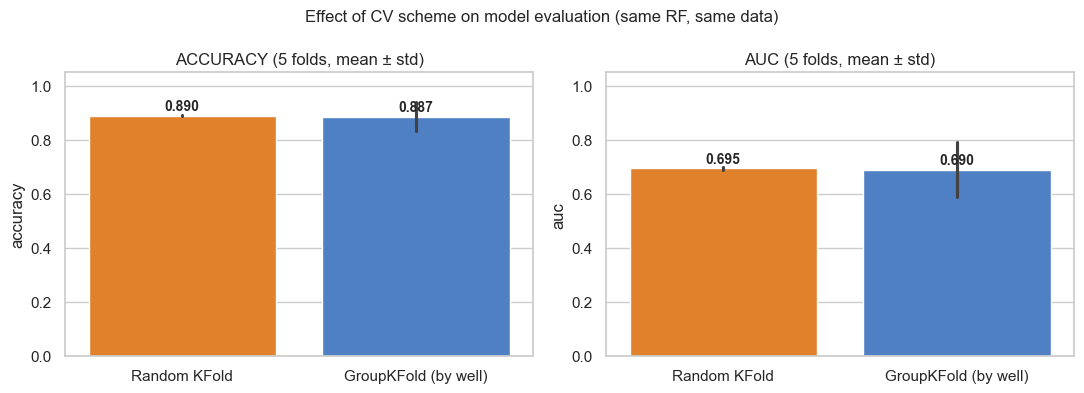


Leakage gap (Random KFold inflation):
  Accuracy: +0.3 percentage points
  AUC:      +0.5 percentage points


In [12]:
# Visual comparison: side-by-side bars for accuracy and AUC
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, metric in zip(axes, ["accuracy", "auc"]):
    sns.barplot(data=cv_compare, x="cv_scheme", y=metric, ax=ax,
                palette={"Random KFold": "#FF7F0E", "GroupKFold (by well)": "#3B7DD8"},
                hue="cv_scheme", legend=False, errorbar="sd")
    ax.set_title(f"{metric.upper()} (5 folds, mean ± std)")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    # annotate the means
    for i, scheme in enumerate(cv_compare["cv_scheme"].unique()):
        m = cv_compare[cv_compare["cv_scheme"] == scheme][metric].mean()
        ax.text(i, m + 0.02, f"{m:.3f}", ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Effect of CV scheme on model evaluation (same RF, same data)", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES / "cv_random_vs_group.png", dpi=200, bbox_inches="tight")
plt.show()

# Save summary
cv_summary.to_csv(TABLES / "cv_random_vs_group.csv")

# Print the leakage gap
gap_acc = res_random["accuracy"].mean() - res_group["accuracy"].mean()
gap_auc = res_random["auc"].mean() - res_group["auc"].mean()
print(f"\nLeakage gap (Random KFold inflation):")
print(f"  Accuracy: +{gap_acc*100:.1f} percentage points")
print(f"  AUC:      +{gap_auc*100:.1f} percentage points")


Random cell-level KFold gives stable but potentially optimistic performance because cells from the same well may appear in both training and test sets. GroupKFold by well is more appropriate for assessing generalization across wells. The GroupKFold results show substantial variability across folds, suggesting that the morphology-based classifier is sensitive to well-level effects and that cell-level random splitting likely overstates model robustness.

## 2.Random Forest vs Logistic Regression vs HistGradientBoosting vs XGBoost

We hold three things constant — the data, the features, and the GroupKFold splits, compare these three models.

- **Logistic Regression**: Fits a single hyperplane through the feature space. Only captures linear effects, but its coefficients are interpretable. 
- **Random Forest**: the model from notebook 04. Captures non-linear interactions, no scaling needed.
- **HistGradientBoosting**: scikit-learn's modern gradient-boosting model. Same family as XGBoost / LightGBM but built into sklearn (no extra install). Usually beats Random Forest on tabular data because it builds trees *sequentially*, with each new tree correcting the previous trees' errors. Supports `class_weight='balanced'` since sklearn 1.4. (I didn't learn this very detailly, AI make this suggestion so I put it here also as a test. I will check it later.)
- **XGBoost**: The most popular gradient boosting library. Same family as HistGradientBoosting but with different defaults.(I get some issue on import XGBoost's package...very strange, trying to fix this)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define each model with the right preprocessing
def build_model(name):
    if name == "Logistic Regression":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ])
    if name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1,
        )
    if name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(
            max_iter=300, class_weight="balanced", random_state=42,
        )
    raise ValueError(name)

MODELS_TO_COMPARE = ["Logistic Regression", "Random Forest", "HistGradientBoosting"]

# Use the SAME GroupKFold splits for all three models so the comparison is fair.
group_kf = GroupKFold(n_splits=5)
splits = list(group_kf.split(X, y, groups))

model_rows = []
for model_name in MODELS_TO_COMPARE:
    print(f"\n=== {model_name} ===")
    for fold_idx, (tr, te) in enumerate(splits):
        clf = build_model(model_name)
        clf.fit(X[tr], y[tr])
        y_pred = clf.predict(X[te])
        y_prob = clf.predict_proba(X[te])[:, 1]
        acc = accuracy_score(y[te], y_pred)
        auc = roc_auc_score(y[te], y_prob)
        model_rows.append({"model": model_name, "fold": fold_idx, "accuracy": acc, "auc": auc})
        print(f"  Fold {fold_idx}: accuracy={acc:.3f}, AUC={auc:.3f}")
models_df = pd.DataFrame(model_rows)



=== Logistic Regression ===
  Fold 0: accuracy=0.712, AUC=0.500
  Fold 1: accuracy=0.757, AUC=0.796
  Fold 2: accuracy=0.724, AUC=0.676
  Fold 3: accuracy=0.700, AUC=0.661
  Fold 4: accuracy=0.756, AUC=0.810

=== Random Forest ===
  Fold 0: accuracy=0.880, AUC=0.525
  Fold 1: accuracy=0.939, AUC=0.767
  Fold 2: accuracy=0.835, AUC=0.700
  Fold 3: accuracy=0.836, AUC=0.678
  Fold 4: accuracy=0.942, AUC=0.779

=== HistGradientBoosting ===
  Fold 0: accuracy=0.780, AUC=0.533
  Fold 1: accuracy=0.834, AUC=0.793
  Fold 2: accuracy=0.783, AUC=0.716
  Fold 3: accuracy=0.736, AUC=0.678
  Fold 4: accuracy=0.831, AUC=0.803


In [16]:
# Summary table: mean ± std per model
model_summary = models_df.groupby("model").agg(
    mean_accuracy=("accuracy", "mean"),
    std_accuracy=("accuracy", "std"),
    mean_auc=("auc", "mean"),
    std_auc=("auc", "std"),
).round(3).sort_values("mean_auc", ascending=False)
model_summary.to_csv(TABLES / "model_comparison.csv")
model_summary


,mean_accuracy,std_accuracy,mean_auc,std_auc
model,,,,
HistGradientBoosting,0.793,0.041,0.704,0.109
Random Forest,0.887,0.053,0.690,0.102
Logistic Regression,0.730,0.026,0.689,0.125


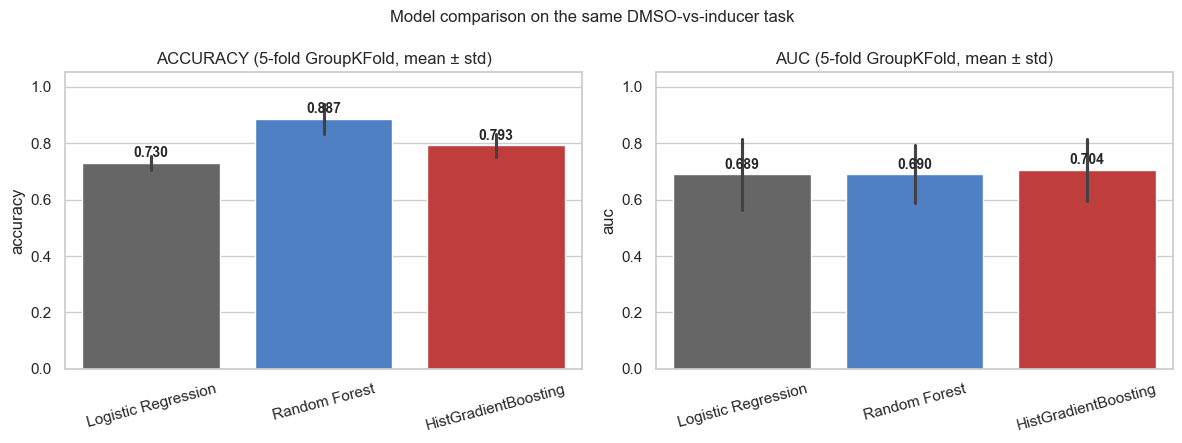

In [17]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
palette = {"Logistic Regression": "#666666", "Random Forest": "#3B7DD8", "HistGradientBoosting": "#D62728"}

for ax, metric in zip(axes, ["accuracy", "auc"]):
    sns.barplot(data=models_df, x="model", y=metric, ax=ax, palette=palette,
                hue="model", legend=False, errorbar="sd",
                order=MODELS_TO_COMPARE)
    ax.set_title(f"{metric.upper()} (5-fold GroupKFold, mean ± std)")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=15)
    for i, m in enumerate(MODELS_TO_COMPARE):
        v = models_df[models_df["model"] == m][metric].mean()
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Model comparison on the same DMSO-vs-inducer task", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES / "model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Per-fold detail (sanity check)

A model can have a great mean AUC but be unstable across folds. Worth checking visually before declaring a winner.

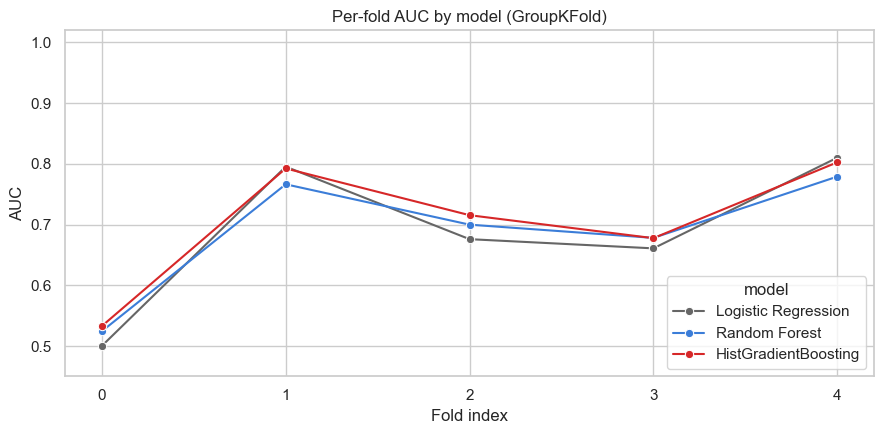

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=models_df, x="fold", y="auc", hue="model", marker="o", ax=ax, palette=palette)
ax.set_title("Per-fold AUC by model (GroupKFold)")
ax.set_ylabel("AUC")
ax.set_xlabel("Fold index")
ax.set_xticks(range(5))
ax.set_ylim(models_df["auc"].min() - 0.05, 1.02)
ax.legend(title="model", loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES / "model_per_fold_auc.png", dpi=200, bbox_inches="tight")
plt.show()
